In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from sys import path
path.append('../fourier/')
import frequency_estimate as fe

In [12]:
window = 500 # Widhint which to compute Periodogram after injection
delay = 300 # How long to wait after injection 
# integration_window = 0.01 # Hz, for integration of the PSD around TGF peak

analysis_kwg = dict(fs=2, 
                    period=60, 
                    signal_band=(0.012, 0.05), 
                    noise_band=(0.5, 0.8)) # before 0.8 Hz because respiration frequency may alias to 0.87

In [17]:
t_inject_veh = 487.85

In [9]:
ds = xr.open_dataset('../../../2024_Kidney_Empagliflozin/Analysis/Register_translation_single_vessels/20241011a_vehicle/20241011a_vehicle_vessel11_REG_INTERP_TimeSeries.nc')

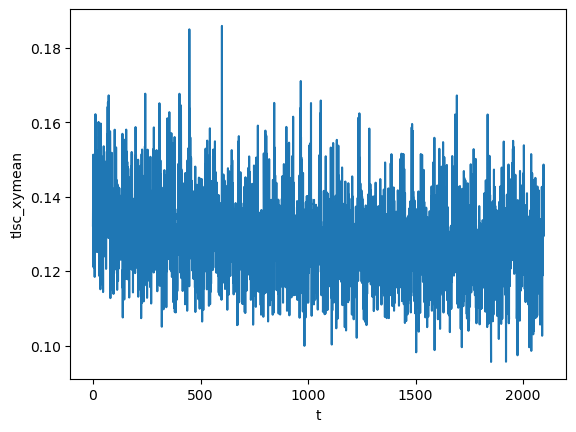

In [14]:
ds.tlsc_xymean.plot()

In [20]:
bsl = ds.tlsc_xymean.sel(t=slice(0, t_inject_veh))
res = ds.tlsc_xymean.sel(t=slice(t_inject_veh+delay,t_inject_veh+delay+window))

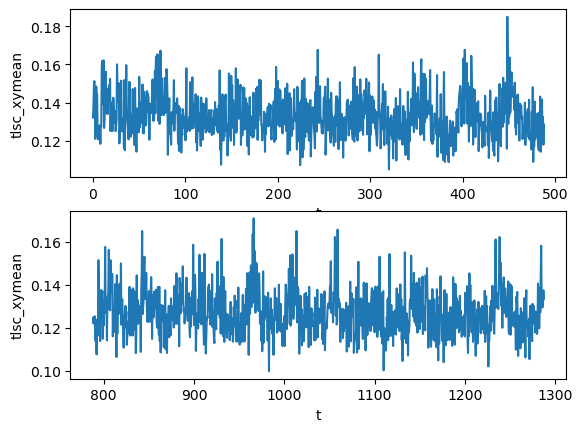

In [24]:
f, (ax,ax1) = plt.subplots(2,1)

bsl.plot(ax=ax)
res.plot(ax=ax1)

In [27]:
p_bsl = fe.symmetric_peak_periodogram(bsl.data, **analysis_kwg)
p_res = fe.symmetric_peak_periodogram(res.data, **analysis_kwg)

In [35]:
p_bsl['num_trimmed'], p_res['num_trimmed']

(10, 110)

In [119]:
bsl_scan = fe.scan_periodogram(bsl.data, 2, max_drop=120, signal_band=(0.01, 0.03))
res_scan = fe.scan_periodogram(res.data, 2, max_drop=150, signal_band=(0.01, 0.03))

(0.0, 0.05)

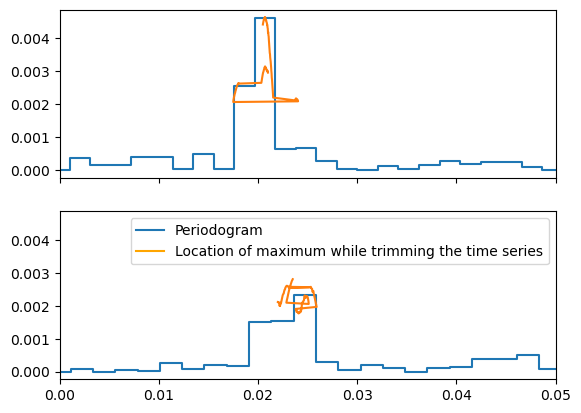

In [144]:
f, (ax,ax1) = plt.subplots(2,1, sharex=True, sharey=True)

ax.step(p_bsl['frequencies'], p_bsl['power'],where='mid')
ax.plot(*bsl_scan)
ax1.step(p_res['frequencies'], p_res['power'], where='mid')
ax1.plot(*res_scan)

ax1.legend(handles=[plt.Line2D([0], [0], label='Periodogram'),
                   plt.Line2D([0], [0], color='orange', label='Location of maximum while trimming the time series')])

ax.set_xlim(0, 0.05)